In [1]:
from pathlib import Path
import numpy as np
import torch
from typing import List
from torch.nn.utils.rnn import pad_sequence
from mltrainer import rnn_models, Trainer
from torch import optim

from mads_datasets import datatools
import mltrainer
mltrainer.__version__

'0.2.4'

In [2]:
# setting the seeds
import random

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.mps.manual_seed(seed)

set_seed(42)

# 1 Iterators
We will be using an interesting dataset. [link](https://tev.fbk.eu/resources/smartwatch)

From the site:
> The SmartWatch Gestures Dataset has been collected to evaluate several gesture recognition algorithms for interacting with mobile applications using arm gestures. Eight different users performed twenty repetitions of twenty different gestures, for a total of 3200 sequences. Each sequence contains acceleration data from the 3-axis accelerometer of a first generation Sony SmartWatch™, as well as timestamps from the different clock sources available on an Android device. The smartwatch was worn on the user's right wrist. 


In [3]:
from mads_datasets import DatasetFactoryProvider, DatasetType
from mltrainer.preprocessors import PaddedPreprocessor
preprocessor = PaddedPreprocessor()

gesturesdatasetfactory = DatasetFactoryProvider.create_factory(DatasetType.GESTURES)
streamers = gesturesdatasetfactory.create_datastreamer(batchsize=32, preprocessor=preprocessor)
train = streamers["train"]
valid = streamers["valid"]

2026-03-07 14:59:08.831 | INFO     | mads_datasets.base:download_data:121 - Folder already exists at /Users/stevenbontius/.cache/mads_datasets/gestures
100%|██████████| 651/651 [00:00<00:00, 5033.01it/s]


In [4]:
len(train), len(valid)

(81, 20)

In [5]:
trainstreamer = train.stream()
validstreamer = valid.stream()
x, y = next(iter(trainstreamer))
x.shape, y

(torch.Size([32, 25, 3]),
 tensor([17,  7,  6, 19,  5,  5,  5,  0,  0, 16, 12,  8,  2, 10, 12,  6,  7, 11,
         14,  4,  4, 10,  8,  1, 18,  1, 10, 17,  5, 19, 18, 12]))

In [6]:
x[0]

tensor([[ -4.4436,   5.8227,   6.7421],
        [ -4.4436,   6.7421,   4.5969],
        [ -1.5323,   8.1211,   5.8227],
        [ -2.1452,   9.0405,   6.8953],
        [ -2.9113,   3.5243,   3.5243],
        [ -2.4517,   2.4517,   1.6855],
        [ -2.2984,  -4.4436,   5.3630],
        [ -6.1292, -11.9519,  15.1697],
        [ -1.3791, -10.2663,  12.8712],
        [  7.9679,   1.3791,  14.7100],
        [  6.7421,   4.2904,   5.9759],
        [  7.3550,   6.2824,   3.6775],
        [ 12.7180,  -5.6695,   9.0405],
        [  8.2744,  -6.2824,  10.1131],
        [  5.3630,  -6.4356,   8.7340],
        [  6.4356,  -3.5243,   8.1211],
        [  5.8227,  -1.8387,   8.1211],
        [  6.1292,  -0.9194,   7.9679],
        [  6.1292,  -1.8387,   8.4276],
        [  6.7421,  -1.0726,   7.9679],
        [  5.9759,  -1.5323,   8.2744],
        [  0.0000,   0.0000,   0.0000],
        [  0.0000,   0.0000,   0.0000],
        [  0.0000,   0.0000,   0.0000],
        [  0.0000,   0.0000,   0.0000]])

Can you make sense of the shape?
What does it mean that the shapes are sometimes (32, 27, 3), but a second time might look like (32, 30, 3)? In other words, the second (or first, if you insist on starting at 0) dimension changes. Why is that? How does the model handle this? Do you think this is already padded, or still has to be padded?

Answers: 

The 2nd dimension are the time steps, since some gestures take more time than others. Longer time, more time steps
Looking at the data it seems that it is padded with 0.00000

The RNN will just process it until the time steps are empty. Tensors need to be all the same size when processed in a batch. Padding all batches to the max size would be a waste of compute since it is only necessary per batch.


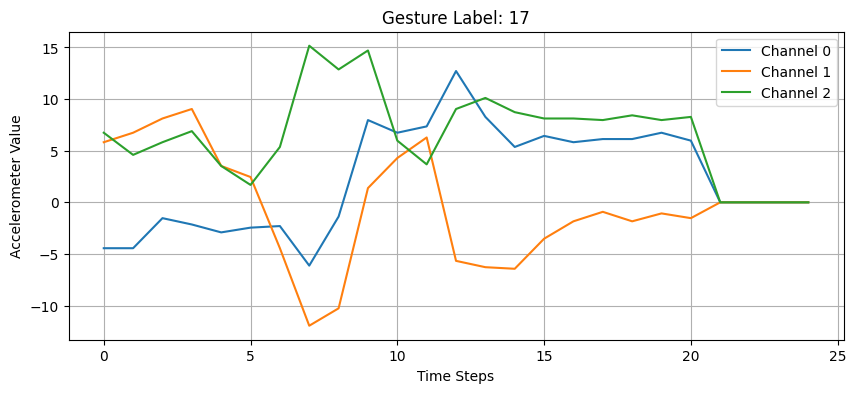

In [7]:
# checking a gesture

import matplotlib.pyplot as plt

def plot_gesture(gesture_data, label):
    # gesture_data shape is (sequence_length, channel)
    plt.figure(figsize=(10, 4))
    plt.plot(gesture_data[:, 0], label='Channel 0')
    plt.plot(gesture_data[:, 1], label='Channel 1')
    plt.plot(gesture_data[:, 2], label='Channel 2')
    
    plt.title(f"Gesture Label: {label}")
    plt.xlabel("Time Steps")
    plt.ylabel("Accelerometer Value")
    plt.legend()
    plt.grid(True)
    plt.show()

# Visualize the first gesture in the batch
# x is (Batch, Time, Channels), y is (Batch)
plot_gesture(x[0], y[0])

In [ ]:
def find_and_plot_gesture(streamer, target_class=0, num_examples=10):
    collected_samples = []
    
    print(f"Hunting for {num_examples} examples of Class {target_class}...")
    
    # max_batches safety limit so it doesn't run forever
    max_batches = 100 
    for _ in range(max_batches):
        if len(collected_samples) >= num_examples:
            break
            
        x, y = next(streamer)
        
        # Find indices where the label matches our target
        matches = (y == target_class).nonzero(as_tuple=True)[0]
        
        for idx in matches:
            if len(collected_samples) < num_examples:
                # Add the matching sequence to our collection
                collected_samples.append(x[idx])
    
    if not collected_samples:
        print("Could not find any examples.")
        return

    # Plotting
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for i, sample in enumerate(collected_samples):
        ax.plot(sample[:, 0].cpu(), color='blue', alpha=0.3)
        ax.plot(sample[:, 1].cpu(), color='red', alpha=0.3)
        ax.plot(sample[:, 2].cpu(), color='green', alpha=0.3)
        
    ax.set_title(f"Overlay of {len(collected_samples)} examples: Class {target_class}")
    ax.set_xlabel("Time Steps")
    ax.set_ylabel("Acceleration")
    plt.show()

Hunting for 50 examples of Class 11...


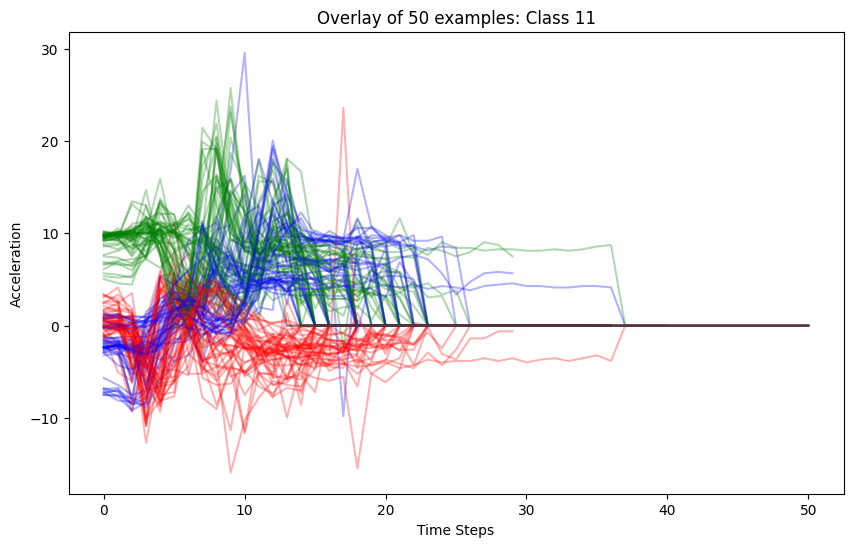

In [9]:
find_and_plot_gesture(train.stream(), target_class=11, num_examples=50)

Hunting for 50 examples of Class 17...


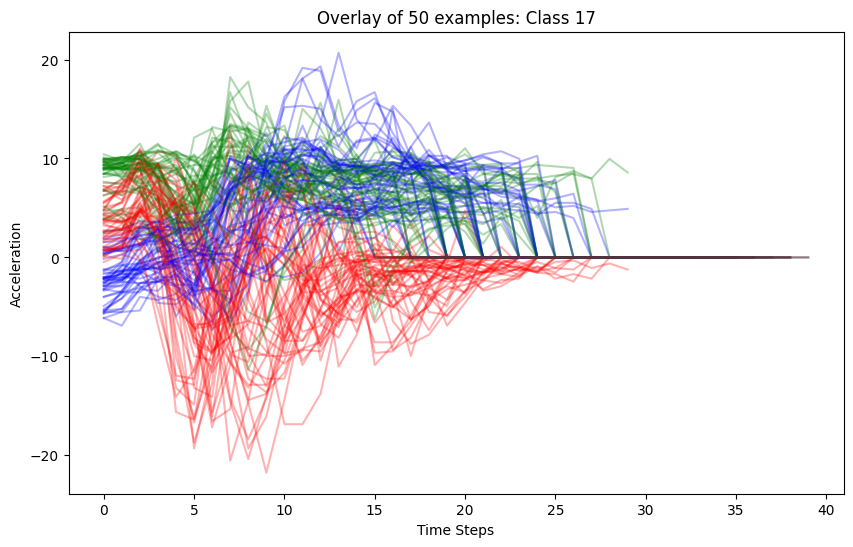

In [10]:
find_and_plot_gesture(train.stream(), target_class=17, num_examples=50)

# 2 Excercises
Lets test a basemodel, and try to improve upon that.

Fill the gestures.gin file with relevant settings for `input_size`, `hidden_size`, `num_layers` and `horizon` (which, in our case, will be the number of classes...)

As a rule of thumbs: start lower than you expect to need!

In [11]:
from mltrainer import TrainerSettings, ReportTypes
from mltrainer.metrics import Accuracy

accuracy = Accuracy()


In [12]:
model = rnn_models.BaseRNN(
    input_size=3,
    hidden_size=64,
    num_layers=1,
    horizon=20,
)

Test the model. What is the output shape you need? Remember, we are doing classification!

input_size = 3 -> we have three features
horizon = 20 -> since there are 20 classes

In [13]:
yhat = model(x)
yhat.shape

torch.Size([32, 20])

In [14]:
y[0], yhat[0]

(tensor(17),
 tensor([-0.0514,  0.0575,  0.1017, -0.0628, -0.0721,  0.0924,  0.1747,  0.0546,
         -0.2142,  0.1406, -0.1642,  0.0228, -0.0324, -0.0778, -0.0497,  0.0813,
          0.1258, -0.0674,  0.0619,  0.0943], grad_fn=<SelectBackward0>))

Test the accuracy

In [15]:
accuracy(y, yhat)

0.0

What do you think of the accuracy? What would you expect from blind guessing?

Random guessing would result in 1/20 = 0.05 so it's slightly better than a random guess. But with the next batch it could be different. This is pure chance.

Check shape of `y` and `yhat`

In [16]:
predictions = yhat.argmax(dim=1)
correct = (predictions == y)
acc = correct.float().mean()
acc, correct

(tensor(0.),
 tensor([False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False, False]))

In this case 2 out of the 32 where correct

In [17]:
yhat[0]

tensor([-0.0514,  0.0575,  0.1017, -0.0628, -0.0721,  0.0924,  0.1747,  0.0546,
        -0.2142,  0.1406, -0.1642,  0.0228, -0.0324, -0.0778, -0.0497,  0.0813,
         0.1258, -0.0674,  0.0619,  0.0943], grad_fn=<SelectBackward0>)

And look at the output of yhat

Does this make sense to you? If you are unclear, go back to the classification problem with the MNIST, where we had 10 classes.

We have a classification problem, so we need Cross Entropy Loss.
Remember, [this has a softmax built in](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html) 

In [18]:
loss_fn = torch.nn.CrossEntropyLoss()
loss = loss_fn(yhat, y)
loss

tensor(3.0194, grad_fn=<NllLossBackward0>)

In [19]:
import math

math.log(20)

2.995732273553991

The cross enthalphy is random guessing see above

In [20]:
import torch
if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    device = torch.device("mps")
    print("Using MPS")
elif torch.cuda.is_available():
    device = "cuda:0"
    print("using cuda")
else:
    device = "cpu"
    print("using cpu")

# on my mac, at least for the BaseRNN model, mps does not speed up training
# probably because the overhead of copying the data to the GPU is too high
# so i override the device to cpu
device = "cpu"
# however, it might speed up training for larger models, with more parameters

Using MPS


Set up the settings for the trainer and the different types of logging you want

In [ ]:
settings = TrainerSettings(
    epochs=100, # increase this to about 100 for training
    metrics=[accuracy],
    logdir=Path("gestures"),
    train_steps=len(train),
    valid_steps=len(valid),
    reporttypes=[ReportTypes.TOML, ReportTypes.TENSORBOARD, ReportTypes.MLFLOW],
    scheduler_kwargs={"factor": 0.5, "patience": 5},
    earlystop_kwargs = {
        "save": False, # save every best model, and restore the best one
        "verbose": True,
        "patience": 5, # number of epochs with no improvement after which training will be stopped
        "delta": 0.0, # minimum change to be considered an improvement
    }
)
settings

epochs: 100
metrics: [Accuracy]
logdir: gestures
train_steps: 81
valid_steps: 20
reporttypes: [<ReportTypes.TOML: 'TOML'>, <ReportTypes.TENSORBOARD: 'TENSORBOARD'>, <ReportTypes.MLFLOW: 'MLFLOW'>]
optimizer_kwargs: {'lr': 0.001, 'weight_decay': 1e-05}
scheduler_kwargs: {'factor': 0.5, 'patience': 5}
earlystop_kwargs: {'save': False, 'verbose': True, 'patience': 5, 'delta': 0.0}

In [22]:
import torch.nn as nn
import torch
from torch import Tensor
from dataclasses import dataclass

@dataclass
class ModelConfig:
    input_size: int
    hidden_size: int
    num_layers: int
    output_size: int
    dropout: float = 0.0

class GRUmodel(nn.Module):
    def __init__(
        self,
        config,
    ) -> None:
        super().__init__()
        self.config = config
        self.rnn = nn.GRU(
            input_size=config.input_size,
            hidden_size=config.hidden_size,
            dropout=config.dropout,
            batch_first=True,
            num_layers=config.num_layers,
        )
        self.linear = nn.Linear(config.hidden_size, config.output_size)

    def forward(self, x: Tensor) -> Tensor:
        x, _ = self.rnn(x)
        last_step = x[:, -1, :]
        yhat = self.linear(last_step)
        return yhat

In [23]:
config = ModelConfig(
    input_size=3,
    hidden_size=64,
    num_layers=1,
    output_size=20,
    dropout=0.0,
)


In [24]:
import mlflow
from datetime import datetime

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("gestures")
modeldir = Path("gestures").resolve()
if not modeldir.exists():
    modeldir.mkdir(parents=True)

with mlflow.start_run():
    mlflow.set_tag("model", "100 epoch base")
    mlflow.set_tag("dev", "Steven")
    config = ModelConfig(
        input_size=3,
        hidden_size=64,
        num_layers=1,
        output_size=20,
        dropout=0.1,
    )

    model = GRUmodel(
        config=config,
    )

    trainer = Trainer(
        model=model,
        settings=settings,
        loss_fn=loss_fn,
        optimizer=optim.Adam,
        traindataloader=trainstreamer,
        validdataloader=validstreamer,
        scheduler=optim.lr_scheduler.ReduceLROnPlateau,
        device=device,
    )
    trainer.loop()

    if not settings.earlystop_kwargs["save"]:
        tag = datetime.now().strftime("%Y%m%d-%H%M-")
        modelpath = modeldir / (tag + "model.pt")
        torch.save(model, modelpath)

/Users/stevenbontius/.local/share/uv/python/cpython-3.11.9-macos-aarch64-none/lib/python3.11/site-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(
2026-03-07 14:59:11.393 | INFO     | mltrainer.trainer:dir_add_timestamp:24 - Logging to gestures/20260307-145911
2026-03-07 14:59:12.065 | INFO     | mltrainer.trainer:__init__:68 - Found earlystop_kwargs in settings.Set to None if you dont want earlystopping.
100%|██████████| 81/81 [00:00<00:00, 354.25it/s]
2026-03-07 14:59:12.362 | INFO     | mltrainer.trainer:report:209 - Epoch 0 train 2.9042 test 2.5903 metric ['0.1141']
100%|██████████| 81/81 [00:00<00:00, 346.99it/s]
2026-03-07 14:59:12.624 | INFO     | mltrainer.trainer:report:209 - Epoch 1 train 2.3606 test 2.2644 metric ['0.1781']
100%|██████████| 81/81 [00:00<00:00, 336.09it/s]
2026-03-07 14:59:12.892 | INFO 

Try to update the code above by changing the hyperparameters.
    
To discern between the changes, also modify the tag mlflow.set_tag("model", "new-tag-here") where you add
a new tag of your choice. This way you can keep the models apart.

In [25]:
mlflow.end_run()

Excercises:

- try to improve the RNN model
- test different things. What works? What does not?
- experiment with either GRU or LSTM layers, create your own models. Have a look at `mltrainer.rnn_models` for inspiration. 
- experiment with adding Conv1D layers. Think about the necessary input-output dimensions of your tensors before and after each layer.

You should be able to get above 90% accuracy with the dataset.
Create a report of 1 a4 about your experiments.

In [26]:
def report_mlflow_confidence(experiment_name=None):
    runs = mlflow.search_runs(
        experiment_names=[experiment_name] if experiment_name else None,
        max_results=1,
        order_by=["start_time DESC"],
        output_format="list",
    )
    if not runs:
        print("No MLflow runs found.")
        return

    metrics = runs[0].data.metrics
    tags = runs[0].data.tags
    run_id = runs[0].info.run_id
    model_name = tags.get("model", "unknown")

    loss = metrics.get("Loss/test")
    accuracy = metrics.get("metric/Accuracy") or 0.0

    if loss is None:
        print(f"Metric 'Loss/test' not found. Available: {list(metrics.keys())}")
        return

    confidence = math.exp(-loss) if loss < 700 else 0.0

    print(f"\nRun: {run_id[:8]} | Model: {model_name}")
    print(f"  Accuracy   : {accuracy:.1%}")
    print(f"  Confidence : {confidence:.1%}  (e^-loss)")
    print(f"  Loss/train : {metrics.get('Loss/train', float('nan')):.4f}")
    print(f"  Loss/test  : {loss:.4f}")

    if confidence > 0.95 and accuracy < 0.7:
        print("  WARNING: high confidence, low accuracy (overconfident model)")
    elif confidence < 0.5:
        print("  NOTE: low confidence (model is uncertain)")


report_mlflow_confidence("gestures")


Run: 4fec40d9 | Model: 100 epoch base
  Accuracy   : 96.9%
  Confidence : 84.4%  (e^-loss)
  Loss/train : 0.0594
  Loss/test  : 0.1701


The results suggest overfitting: the training loss (0.011) is much lower than the test loss (0.147), indicating the model fits the training data far better than unseen data. Despite this gap, the test accuracy remains high at 96.7% on a 20-class task. The cross-entropy loss implies that the model assigns an average probability of about ≈ 0.86 to the correct class, meaning predictions are often correct but not extremely confident. To rule out potential data leakage or shortcut learning (e.g., near-duplicate recordings across splits), the dataset splits should be verified and performance evaluated on a fully independent test set.

Looking at the GesturesFactory we find that the train test split is done via a standard 80/20 split.

```
split = kwargs.pop("split", 0.8)
        idx = int(len(paths) * split)
        trainpaths = paths[:idx]
        validpaths = paths[idx:]
```

Each user performs each gesture 20 times, so for user U01 performing gesture 7 there are 20 recordings representing the same motion with small variations in timing and magnitude. A random 80/20 split shuffles all 3200 recordings before splitting, which means that recordings from the same user performing the same gesture appear in both the training and validation sets. For example, roughly 16 recordings of U01 performing gesture 7 may appear in training and the remaining 4 in validation.
As a result, the model is validated on samples that are highly correlated with its training data. Rather than learning a user-independent representation of the gesture, the model may partially rely on user-specific movement patterns. The validation set therefore does not represent truly unseen data but rather slight variations of motions from users already observed during training. Consequently, the reported validation accuracy (e.g., 99.69%) likely overestimates the model’s ability to generalize to new users. 

A more appropriate evaluation would use a subject-wise split (e.g., leave-one-subject-out), where all recordings from certain users are held out for testing.

## Changing to correct test train split

In total there are 8 users and in total 20 gestures. Each gesture is repeated 20 times by the user.

To get a better test train split we will apply the Leave One Subject Out (LOSO) technique.



In [27]:
import shutil
from copy import deepcopy
from pathlib import Path
from typing import Any, Mapping

from mads_datasets.base import AbstractDatasetFactory, DatasetProtocol
from mads_datasets.datasets import TSDataset
from mads_datasets.datatools import keep_subdirs_only, walk_dir
from mads_datasets.settings import DatasetSettings, gesturesdatasetsettings


class CorrectGesturesFactory(AbstractDatasetFactory[DatasetSettings]):
    """
    Splits by user ID (leave-one-user-out) instead of random file shuffle.
    Pass the held-out user ID as a string, e.g. "U01", to create_dataset().
    All files from that user go to valid; all others go to train.
    """

    def __init__(self, settings: DatasetSettings, **kwargs: Any) -> None:
        super().__init__(settings, **kwargs)
        self._created = False
        self.datasets: Mapping[str, DatasetProtocol]

    def create_dataset(
        self, *args: Any, **kwargs: Any
    ) -> Mapping[str, DatasetProtocol]:
        self.download_data()

        if self._created:
            return deepcopy(self.datasets)

        # --- resolve held-out user ---
        holdout_user: str = kwargs.pop("holdout_user", "U01")

        formats = [f.value for f in self._settings.formats]
        datadir = self.subfolder / "gestures-dataset"

        # mirror what the original factory does before splitting
        img = datadir / "gestures.png"
        if img.exists():
            shutil.move(img, datadir.parent / "gestures.png")
        keep_subdirs_only(datadir)

        paths = [p for p in walk_dir(datadir) if p.suffix in formats]

        # path structure: .../gestures-dataset/{UserID}/{SessionID}/{GestureClass}.txt
        trainpaths = [p for p in paths if p.parts[-3] != holdout_user]
        validpaths = [p for p in paths if p.parts[-3] == holdout_user]

        if not validpaths:
            available = sorted({p.parts[-3] for p in paths})
            raise ValueError(
                f"No files found for user '{holdout_user}'. "
                f"Available users: {available}"
            )

        train_users = {p.parts[-3] for p in trainpaths}
        valid_users = {p.parts[-3] for p in validpaths}

        assert train_users.isdisjoint(valid_users), "LEAK: users appear in both splits!"
        print(f"Train users: {sorted(train_users)}")
        print(f"Valid users: {sorted(valid_users)}")

        traindataset = TSDataset(trainpaths)
        validdataset = TSDataset(validpaths)

        datasets = {"train": traindataset, "valid": validdataset}
        self.datasets = datasets  # type: ignore
        self._created = True
        return datasets


In [28]:
from mltrainer.preprocessors import PaddedPreprocessor

datadir = Path.home() / ".cache/mads_datasets"
correct_factory = CorrectGesturesFactory(gesturesdatasetsettings, datadir=datadir)
correct_datasets = correct_factory.create_dataset(holdout_user="U01")

preprocessor = PaddedPreprocessor()

correct_streamers = correct_factory.create_datastreamer(batchsize=32, preprocessor=preprocessor)
correct_train_streamer = correct_streamers["train"].stream()
correct_valid_streamer = correct_streamers["valid"].stream()

settings.train_steps = len(correct_streamers["train"])
settings.valid_steps = len(correct_streamers["valid"])

2026-03-07 14:59:23.808 | INFO     | mads_datasets.base:download_data:121 - Folder already exists at /Users/stevenbontius/.cache/mads_datasets/gestures


Train users: ['U02', 'U03', 'U04', 'U05', 'U06', 'U07', 'U08']
Valid users: ['U01']


100%|██████████| 401/401 [00:00<00:00, 7879.45it/s]
2026-03-07 14:59:24.741 | INFO     | mads_datasets.base:download_data:121 - Folder already exists at /Users/stevenbontius/.cache/mads_datasets/gestures


### Checking the same model with the correct split

In [29]:
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("gestures")
modeldir = Path("gestures").resolve()
if not modeldir.exists():
    modeldir.mkdir(parents=True)

with mlflow.start_run():
    mlflow.set_tag("model", "100 epoch base correct split")
    mlflow.set_tag("dev", "Steven")
    config = ModelConfig(
        input_size=3,
        hidden_size=64,
        num_layers=1,
        output_size=20,
        dropout=0.1,
    )

    model = GRUmodel(
        config=config,
    )

    trainer = Trainer(
        model=model,
        settings=settings,
        loss_fn=loss_fn,
        optimizer=optim.Adam,
        traindataloader=correct_train_streamer,
        validdataloader=correct_valid_streamer,
        scheduler=optim.lr_scheduler.ReduceLROnPlateau,
        device=device,
    )

    trainer.loop()

    if not settings.earlystop_kwargs["save"]:
        tag = datetime.now().strftime("%Y%m%d-%H%M-")
        modelpath = modeldir / (tag + "model.pt")
        torch.save(model, modelpath)

/Users/stevenbontius/.local/share/uv/python/cpython-3.11.9-macos-aarch64-none/lib/python3.11/site-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(
2026-03-07 14:59:24.821 | INFO     | mltrainer.trainer:dir_add_timestamp:24 - Logging to gestures/20260307-145924
2026-03-07 14:59:24.822 | INFO     | mltrainer.trainer:__init__:68 - Found earlystop_kwargs in settings.Set to None if you dont want earlystopping.
100%|██████████| 89/89 [00:00<00:00, 356.75it/s]
2026-03-07 14:59:25.095 | INFO     | mltrainer.trainer:report:209 - Epoch 0 train 2.8419 test 2.5064 metric ['0.1172']
100%|██████████| 89/89 [00:00<00:00, 367.12it/s]
2026-03-07 14:59:25.358 | INFO     | mltrainer.trainer:report:209 - Epoch 1 train 2.2724 test 2.2816 metric ['0.1562']
100%|██████████| 89/89 [00:00<00:00, 362.64it/s]
2026-03-07 14:59:25.623 | INFO 

In [30]:
report_mlflow_confidence("gestures")


Run: 0e366dcc | Model: 100 epoch base correct split
  Accuracy   : 82.3%
  Confidence : 38.2%  (e^-loss)
  Loss/train : 0.0728
  Loss/test  : 0.9611
  NOTE: low confidence (model is uncertain)


The models stops after 27 epocs since it cannot learn anymore. Test loss increased significantly. Train loss is low and indicative of overfitting.

The goal is to reach a model that performs better than 90%. 

The issue now is that we do not know if the U01 user is a particular hard user to predict. So we are going to do a cross validation across all users.

## Cross validate all users

In [ ]:
user_ids =  ['U01', 'U02', 'U03', 'U04', 'U05', 'U06', 'U07', 'U08']

config = ModelConfig(
            input_size=3,
            hidden_size=64,
            num_layers=1,
            output_size=20,
            dropout=0.1,
        )

for user_id in user_ids:
    # create factory and streamers
    correct_factory = CorrectGesturesFactory(gesturesdatasetsettings, datadir=datadir)
    correct_datasets = correct_factory.create_dataset(holdout_user=user_id)
    correct_streamers = correct_factory.create_datastreamer(batchsize=32, preprocessor=preprocessor)
    correct_train_streamer = correct_streamers["train"].stream()
    correct_valid_streamer = correct_streamers["valid"].stream()

    with mlflow.start_run():
        mlflow.set_tag("model", f"base correct split hold out: {user_id}")
        mlflow.set_tag("dev", "Steven")
        
        model = GRUmodel(
            config=config,
        )

        trainer = Trainer(
            model=model,
            settings=settings,
            loss_fn=loss_fn,
            optimizer=optim.Adam,
            traindataloader=correct_train_streamer,
            validdataloader=correct_valid_streamer,
            scheduler=optim.lr_scheduler.ReduceLROnPlateau,
            device=device,
        )
        trainer.loop()

    

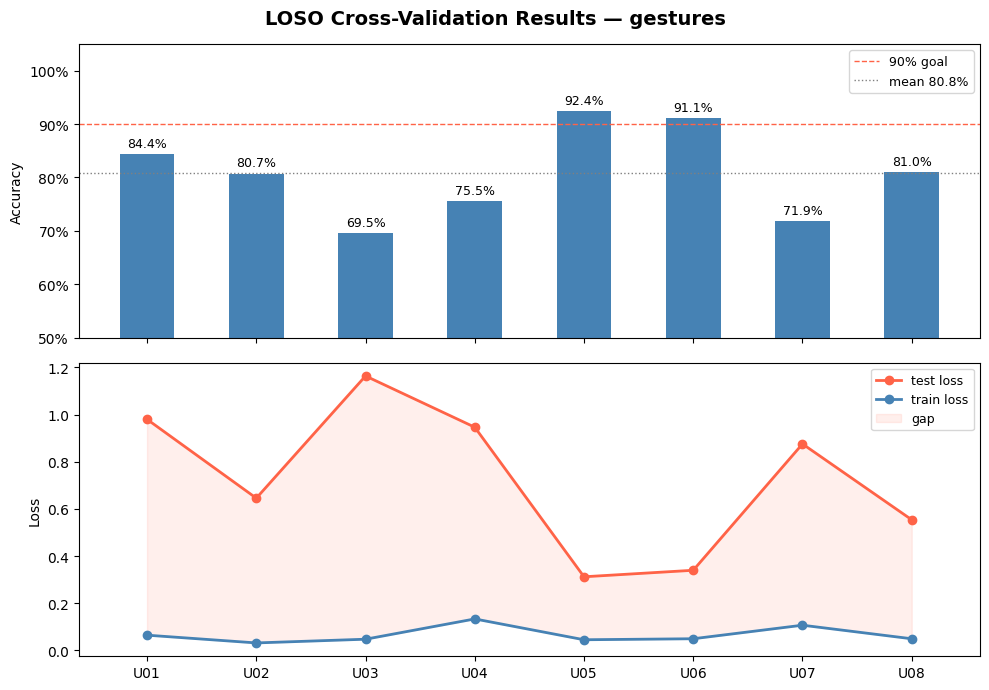

In [32]:
def plot_loso_results(experiment_name: str, save_path: str = "loso_results.png") -> None:
    runs = mlflow.search_runs(
        experiment_names=[experiment_name],
        output_format="list",
    )

    results = sorted(
        [
            {
                "user":       run.data.tags.get("model", "").split("hold out:")[-1].strip(),
                "accuracy":   run.data.metrics.get("metric/Accuracy", 0.0),
                "test_loss":  run.data.metrics.get("Loss/test", 0.0),
                "train_loss": run.data.metrics.get("Loss/train", 0.0),
            }
            for run in runs
            if "hold out" in run.data.tags.get("model", "")
        ],
        key=lambda r: r["user"],
    )

    if not results:
        raise ValueError(f"No LOSO runs found in experiment '{experiment_name}'.")

    users      = [r["user"] for r in results]
    accuracy   = [r["accuracy"] for r in results]
    test_loss  = [r["test_loss"] for r in results]
    train_loss = [r["train_loss"] for r in results]
    x = np.arange(len(users))

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
    fig.suptitle(f"LOSO Cross-Validation Results — {experiment_name}", fontsize=14, fontweight="bold")

    bars = ax1.bar(x, accuracy, color="steelblue", width=0.5)
    ax1.axhline(0.9, color="tomato", linestyle="--", linewidth=1, label="90% goal")
    ax1.axhline(np.mean(accuracy), color="grey", linestyle=":", linewidth=1, label=f"mean {np.mean(accuracy):.1%}")
    ax1.set_ylabel("Accuracy")
    ax1.set_ylim(0.5, 1.05)
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax1.legend(fontsize=9)
    ax1.bar_label(bars, fmt=lambda v: f"{v:.1%}", padding=3, fontsize=9)

    ax2.plot(x, test_loss,  marker="o", color="tomato",    label="test loss",  linewidth=2)
    ax2.plot(x, train_loss, marker="o", color="steelblue", label="train loss", linewidth=2)
    ax2.fill_between(x, train_loss, test_loss, alpha=0.1, color="tomato", label="gap")
    ax2.set_ylabel("Loss")
    ax2.set_xticks(x)
    ax2.set_xticklabels(users)
    ax2.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

plot_loso_results("gestures")

The experiment shows that the hold out set determines the accuracy and loss significantly. The question in this case will be what are we optimizing. It begs the question if the dataset is representative for a real world application. In a real world case the amount of users that are tested would be significantly higher in order to create a good generalizing model. 

In [33]:
settings

epochs: 100
metrics: [Accuracy]
logdir: gestures
train_steps: 89
valid_steps: 12
reporttypes: [<ReportTypes.TOML: 'TOML'>, <ReportTypes.TENSORBOARD: 'TENSORBOARD'>, <ReportTypes.MLFLOW: 'MLFLOW'>]
optimizer_kwargs: {'lr': 0.001, 'weight_decay': 1e-05}
scheduler_kwargs: {'factor': 0.5, 'patience': 5}
earlystop_kwargs: {'save': False, 'verbose': True, 'patience': 5, 'delta': 0.0}

The patience for both optimizer and scheduler are the same. By the time the scheduler fires and want to change the learning rate the early stopping also kicks in and stops the model. First thing to tackle is to create some room for the scheduler to do its work.

In [34]:
settings.earlystop_kwargs["patience"] = 10

In [35]:
def run_loso(
    experiment_name: str,
    config: ModelConfig,
    settings: TrainerSettings,
    loss_fn,
    device,
    preprocessor,
    model_tag: str = "base correct split",
    user_ids: list = ['U01', 'U02', 'U03', 'U04', 'U05', 'U06', 'U07', 'U08'],
) -> None:
    mlflow.set_experiment(experiment_name)
    datadir = Path.home() / ".cache/mads_datasets"

    for user_id in user_ids:
        factory = CorrectGesturesFactory(gesturesdatasetsettings, datadir=datadir)
        datasets = factory.create_dataset(holdout_user=user_id)
        streamers = factory.create_datastreamer(batchsize=32, preprocessor=preprocessor)

        settings.train_steps = len(streamers["train"])
        settings.valid_steps = len(streamers["valid"])
        
        with mlflow.start_run():
            mlflow.set_tag("model", f"{model_tag} hold out: {user_id}")
            mlflow.set_tag("dev", "Steven")

            trainer = Trainer(
                model=GRUmodel(config=config),
                settings=settings,
                loss_fn=loss_fn,
                optimizer=optim.Adam,
                traindataloader=streamers["train"].stream(),
                validdataloader=streamers["valid"].stream(),
                scheduler=optim.lr_scheduler.ReduceLROnPlateau,
                device=device,
            )
            trainer.loop()

In [ ]:
run_loso(
    experiment_name="patient_gestures",
    model_tag="More patient early stopping",
    config=config,
    settings=settings,
    loss_fn=loss_fn,
    device=device,
    preprocessor=preprocessor,
)

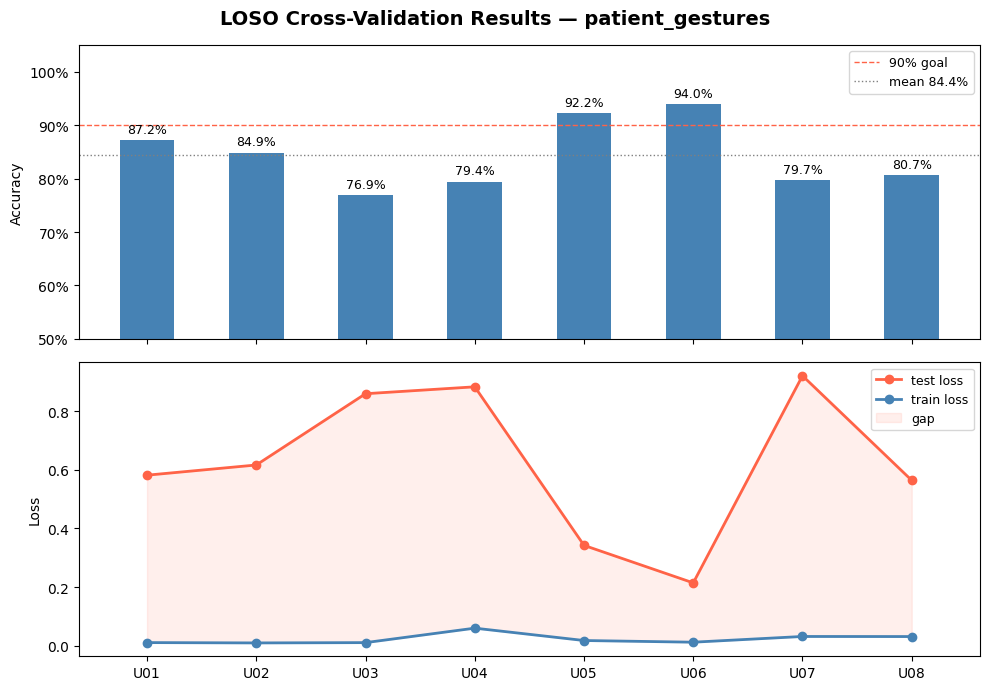

In [37]:
plot_loso_results("patient_gestures")

The mean accuracy has been increased from 80.8 to 84.4 The lowest performing model is worse than in the other experiment.

There are still signs of overfitting. Lets try to increase dropout.

In [38]:
config.dropout = 0.3

In [ ]:
run_loso(
    experiment_name="patient_gestures_drop_out",
    model_tag="More patient early stopping with 0.3 drop out",
    config=config,
    settings=settings,
    loss_fn=loss_fn,
    device=device,
    preprocessor=preprocessor,
)

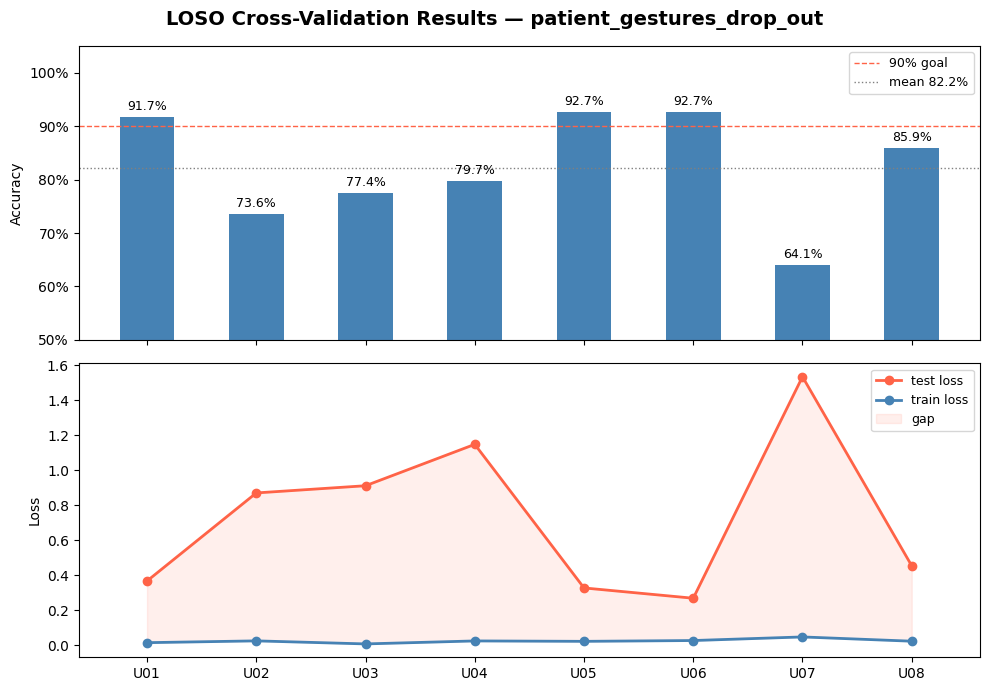

In [40]:
plot_loso_results("patient_gestures_drop_out")

Dropout settings of 0.3 and 0.5 do not have a favourable outcome on the results. So is the overfitting an issue of model capacity, or the data itself?

Is data augmentation a solution? Lets add noise

In [45]:
from torch.utils.data import Dataset

class AugmentedDataset(Dataset):
    def __init__(self, dataset: Dataset, noise_std: float = 0.05, scale_range: tuple = (0.9, 1.1)):
        self.dataset = dataset
        self.noise_std = noise_std
        self.scale_range = scale_range

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        x, y = self.dataset[idx]
        x = x + torch.randn_like(x) * self.noise_std
        x = x * torch.FloatTensor(1).uniform_(*self.scale_range)
        return x, y

In [ ]:
def run_loso_augmented(
    experiment_name: str,
    config: ModelConfig,
    settings: TrainerSettings,
    loss_fn,
    device,
    preprocessor,
    model_tag: str = "Base model",
    noise_std: float = 0.05,
    scale_range: tuple = (0.9, 1.1),
    user_ids: list = ['U01', 'U02', 'U03', 'U04', 'U05', 'U06', 'U07', 'U08'],
) -> None:
    mlflow.set_experiment(experiment_name)
    datadir = Path.home() / ".cache/mads_datasets"

    for user_id in user_ids:
        factory = CorrectGesturesFactory(gesturesdatasetsettings, datadir=datadir)
        datasets = factory.create_dataset(holdout_user=user_id)
        factory.datasets["train"] = AugmentedDataset(
            datasets["train"], noise_std=noise_std, scale_range=scale_range
        )
        streamers = factory.create_datastreamer(batchsize=32, preprocessor=preprocessor)

        settings.train_steps = len(streamers["train"])
        settings.valid_steps = len(streamers["valid"])

        with mlflow.start_run():
            mlflow.set_tag("model", f"{model_tag} hold out: {user_id}")
            mlflow.set_tag("dev", "Steven")

            trainer = Trainer(
                model=GRUmodel(config=config),
                settings=settings,
                loss_fn=loss_fn,
                optimizer=optim.Adam,
                traindataloader=streamers["train"].stream(),
                validdataloader=streamers["valid"].stream(),
                scheduler=optim.lr_scheduler.ReduceLROnPlateau,
                device=device,
            )
            trainer.loop()

In [42]:
# set drop out back
config.dropout = 0.1

In [ ]:
run_loso_augmented(
    experiment_name="patient_augmented",
    model_tag="More patient early stopping with noise augmentation",
    config=config,
    settings=settings,
    loss_fn=loss_fn,
    device=device,
    preprocessor=preprocessor,
)

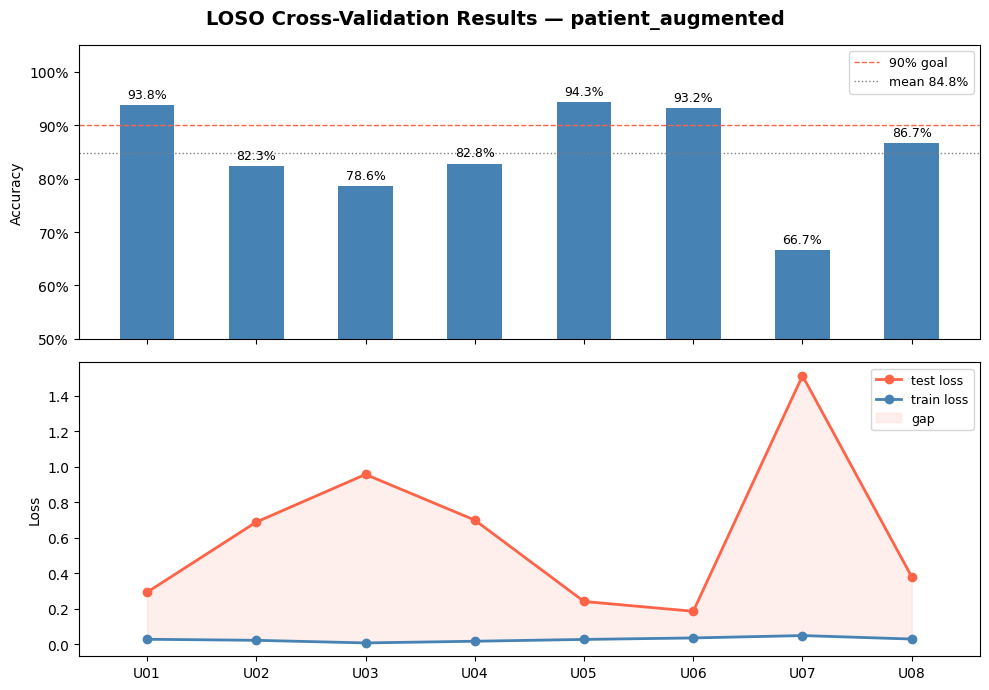

In [47]:
plot_loso_results("patient_augmented")

In [ ]:
run_loso_augmented(
    experiment_name="patient_augmented_strong",
    model_tag="More patient early stopping with more noise augmentation",
    config=config,
    settings=settings,
    loss_fn=loss_fn,
    device=device,
    preprocessor=preprocessor,
    noise_std=0.15,
    scale_range=(0.7, 1.3)
)

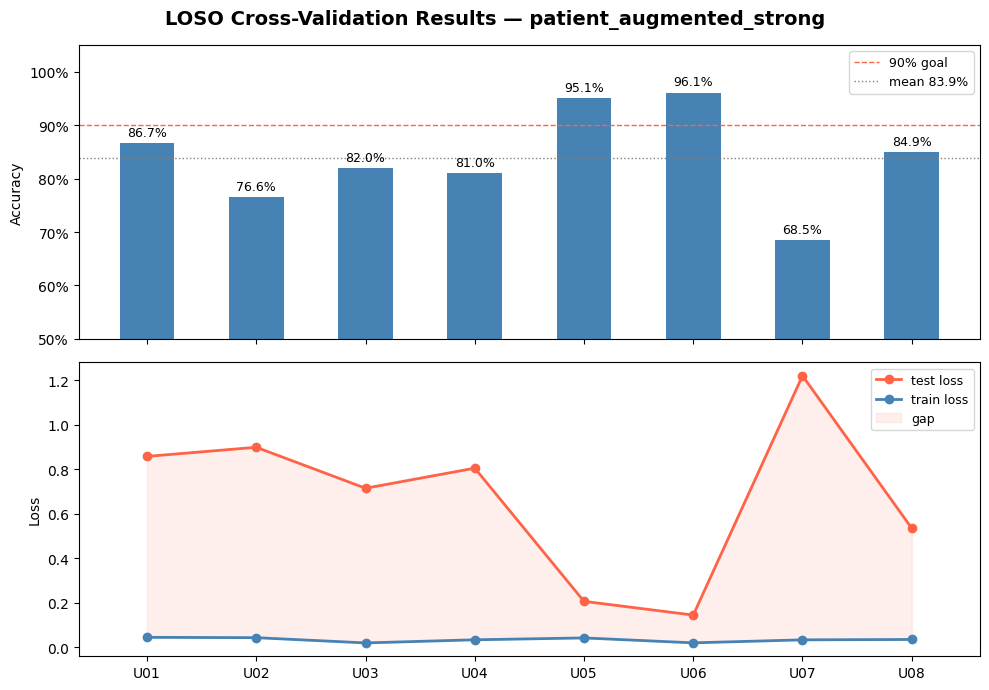

In [49]:
plot_loso_results("patient_augmented_strong")

It appears that augmenting the data does not increase the performance of the model. So we are going to ditch that. I guess there is too little user data to make this model perform good. But lets try anyway.

## Trying some more regularization

In [ ]:
# deep copy
std_settings = deepcopy(settings)
std_config = deepcopy(config)

In [76]:
weight_settings = deepcopy(std_settings)
weight_settings.optimizer_kwargs['weight_decay'] = 1e-03
weight_settings

epochs: 100
metrics: [Accuracy]
logdir: gestures
train_steps: 89
valid_steps: 12
reporttypes: [<ReportTypes.TOML: 'TOML'>, <ReportTypes.TENSORBOARD: 'TENSORBOARD'>, <ReportTypes.MLFLOW: 'MLFLOW'>]
optimizer_kwargs: {'lr': 0.001, 'weight_decay': 0.001}
scheduler_kwargs: {'factor': 0.5, 'patience': 5}
earlystop_kwargs: {'save': False, 'verbose': True, 'patience': 10, 'delta': 0.0}

In [ ]:
run_loso(
    experiment_name="patient_increased_weight_decay",
    model_tag="More patient early stopping with higher weight decay",
    config=std_config,
    settings=weight_settings,
    loss_fn=loss_fn,
    device=device,
    preprocessor=preprocessor,
)

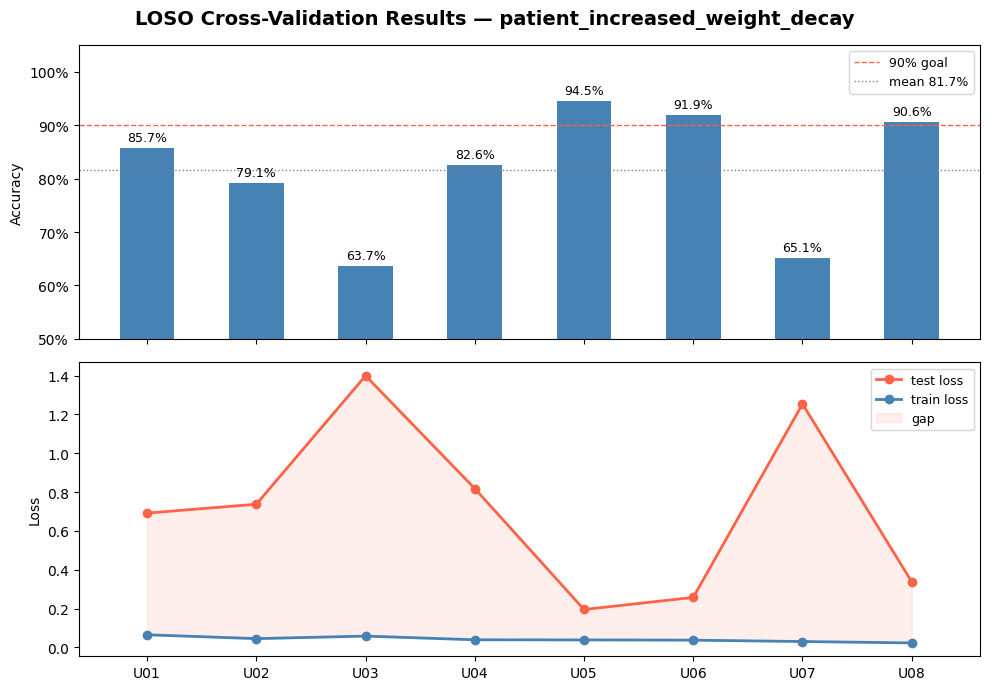

In [79]:
plot_loso_results("patient_increased_weight_decay")

Regularization seems not to do a lot. Let's increase the models capacity.

## Increasing capacity

first make a copy of the settings and config and make it standard so we can easily refer back to it.

In [82]:
weight_settings

epochs: 100
metrics: [Accuracy]
logdir: gestures
train_steps: 89
valid_steps: 12
reporttypes: [<ReportTypes.TOML: 'TOML'>, <ReportTypes.TENSORBOARD: 'TENSORBOARD'>, <ReportTypes.MLFLOW: 'MLFLOW'>]
optimizer_kwargs: {'lr': 0.001, 'weight_decay': 0.001}
scheduler_kwargs: {'factor': 0.5, 'patience': 5}
earlystop_kwargs: {'save': False, 'verbose': True, 'patience': 10, 'delta': 0.0}

In [86]:
# weight decay is somehow changed in std settings, revert to standard
std_settings.optimizer_kwargs['weight_decay']=1e-5

In [88]:
larger_config = deepcopy(std_config)
larger_config.num_layers = 2

In [ ]:
run_loso(
    experiment_name="std_2_layers",
    model_tag="std_2_layers",
    config=larger_config,
    settings=std_settings,
    loss_fn=loss_fn,
    device=device,
    preprocessor=preprocessor,
)

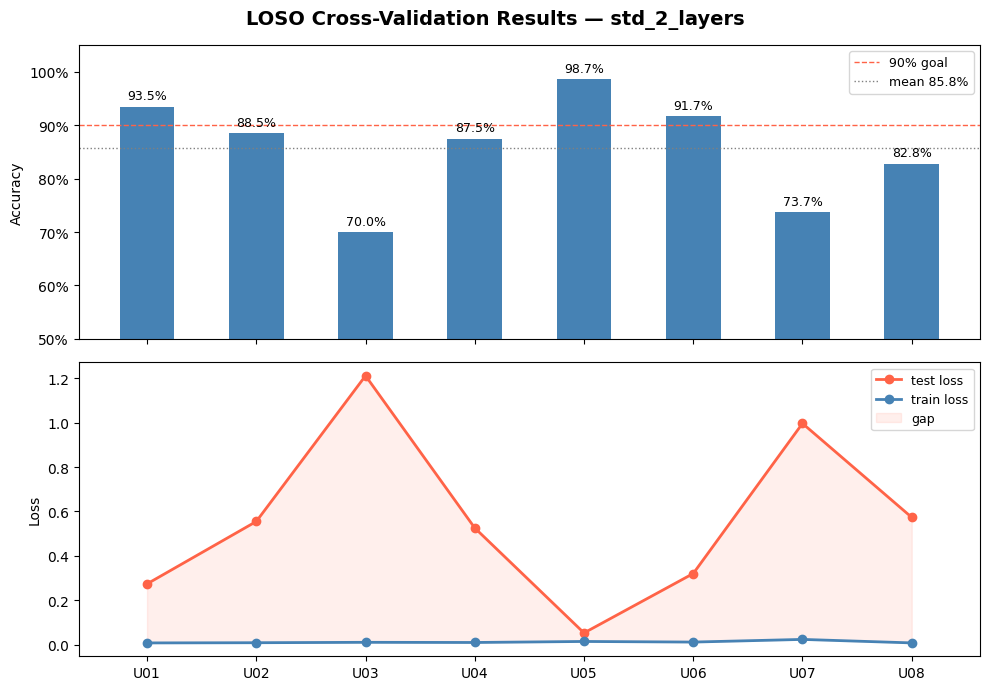

In [91]:
plot_loso_results("std_2_layers")

Looks promising, mean was increased to 85.8 and lowest accuracy was increased loss came down as well. However, this model did not work for all hold outs. Some users got a worse score. 

Lets increase the layers once more.

In [92]:
larger_config.num_layers = 3
larger_config

ModelConfig(input_size=3, hidden_size=64, num_layers=3, output_size=20, dropout=0.1)

In [ ]:
run_loso(
    experiment_name="std_3_layers",
    model_tag="std_3_layers",
    config=larger_config,
    settings=std_settings,
    loss_fn=loss_fn,
    device=device,
    preprocessor=preprocessor,
)

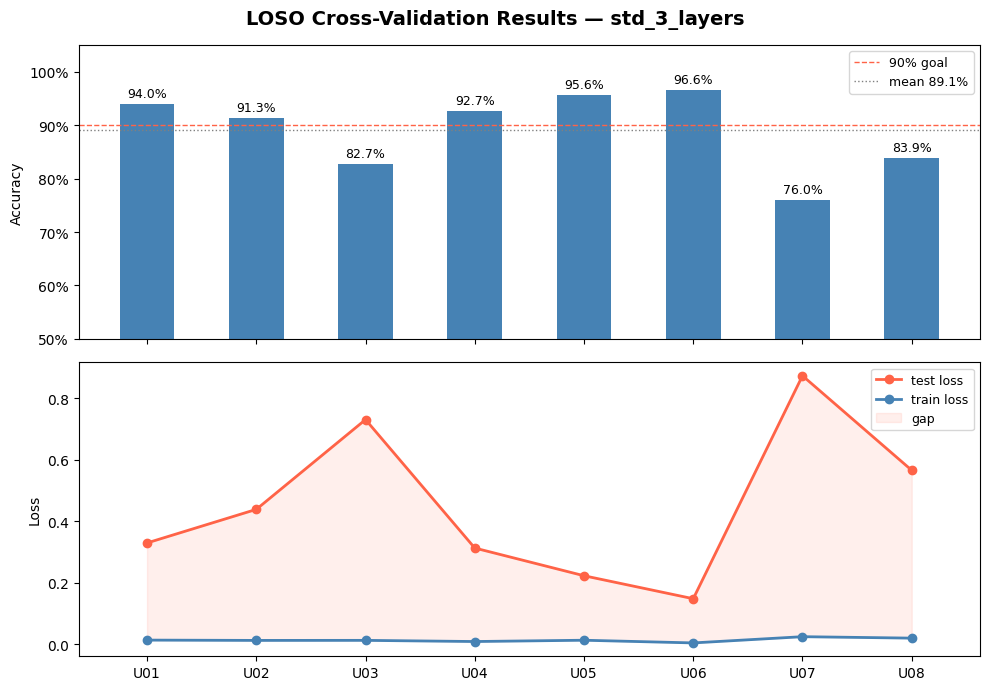

In [94]:
plot_loso_results("std_3_layers")

Accuracy increased again, lets add another layer to see if it still creases. 

In [95]:
larger_config.num_layers = 4

In [ ]:
run_loso(
    experiment_name="std_4_layers",
    model_tag="std_4_layers",
    config=larger_config,
    settings=std_settings,
    loss_fn=loss_fn,
    device=device,
    preprocessor=preprocessor,
)

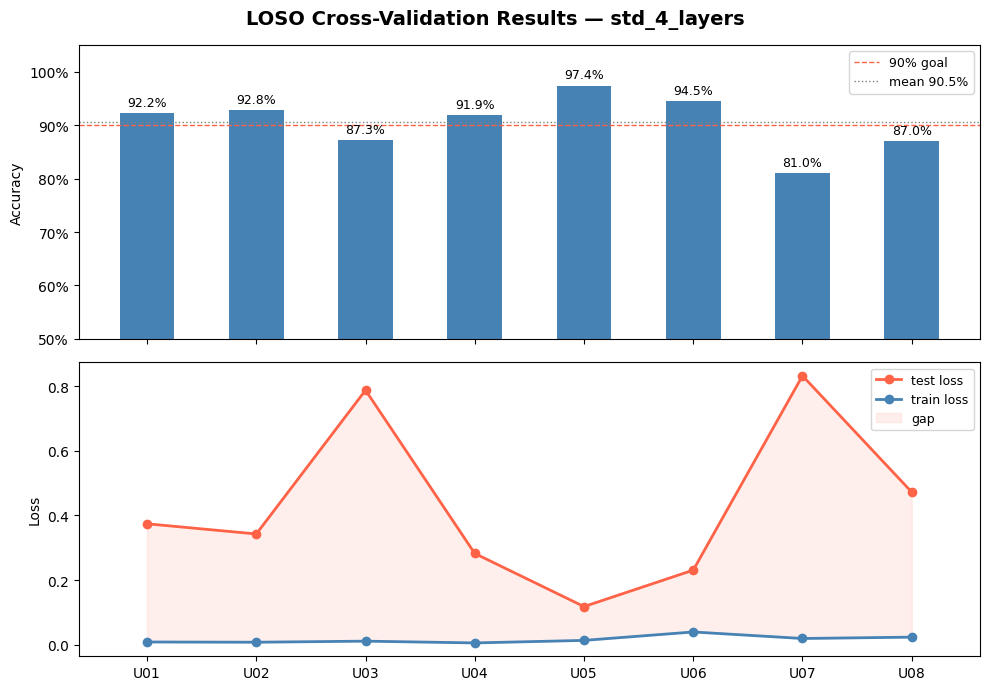

In [97]:
plot_loso_results("std_4_layers")

The effect of the 4th layer seems to be very small, so 3 layers seems to be good.

However, the goal of 90% is reached.

Since there is more capacity, lets try dropout again

In [101]:
larger_config.num_layers = 3
larger_config.dropout = 0.3

In [ ]:
run_loso(
    experiment_name="std_3_layers_drop_0.3",
    model_tag="std_3_layers_drop_0.3",
    config=larger_config,
    settings=std_settings,
    loss_fn=loss_fn,
    device=device,
    preprocessor=preprocessor,
)

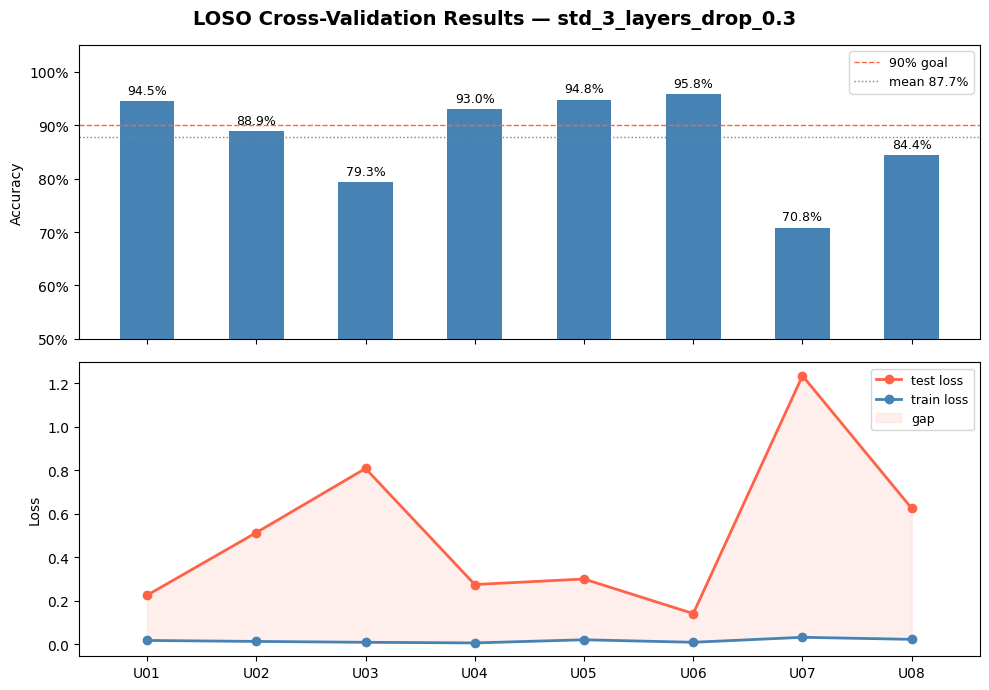

In [105]:
plot_loso_results("std_3_layers_drop_0.3")

Add 4th layer and add drop out

In [106]:
larger_config.num_layers = 4

In [107]:
larger_config

ModelConfig(input_size=3, hidden_size=64, num_layers=4, output_size=20, dropout=0.3)

In [ ]:
run_loso(
    experiment_name="std_4_layers_drop_0.3",
    model_tag="std_4_layers_drop_0.3",
    config=larger_config,
    settings=std_settings,
    loss_fn=loss_fn,
    device=device,
    preprocessor=preprocessor,
)

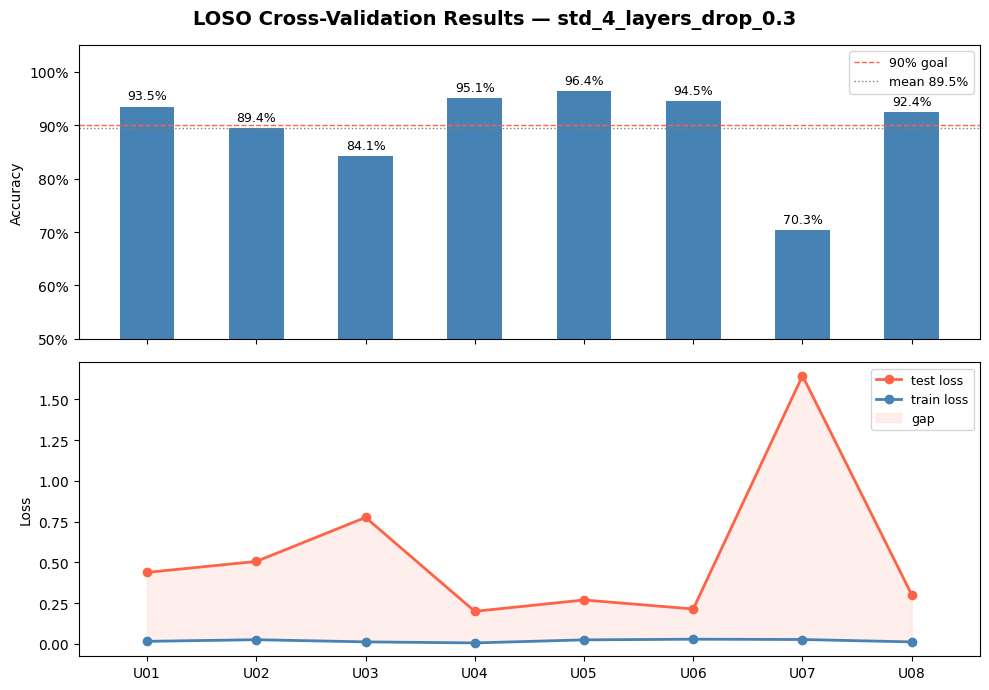

In [ ]:
§plot_loso_results("std_4_layers_drop_0.3")

4 layers with std drop out still the best

In [112]:
settings

epochs: 100
metrics: [Accuracy]
logdir: gestures
train_steps: 89
valid_steps: 12
reporttypes: [<ReportTypes.TOML: 'TOML'>, <ReportTypes.TENSORBOARD: 'TENSORBOARD'>, <ReportTypes.MLFLOW: 'MLFLOW'>]
optimizer_kwargs: {'lr': 0.001, 'weight_decay': 0.001}
scheduler_kwargs: {'factor': 0.5, 'patience': 5}
earlystop_kwargs: {'save': False, 'verbose': True, 'patience': 10, 'delta': 0.0}

## Adding a conv layer to improve performance

In [ ]:
class Conv1DGRUModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
        )
        self.gru = nn.GRU(
            input_size=32,
            hidden_size=config.hidden_size,
            num_layers=config.num_layers,
            dropout=config.dropout,
            batch_first=True,
        )
        self.linear = nn.Linear(config.hidden_size, config.output_size)

    def forward(self, x):
        # x shape: (batch, seq, features) -> conv expects (batch, features, seq)
        x = self.conv(x.permute(0, 2, 1)).permute(0, 2, 1)
        out, _ = self.gru(x)
        return self.linear(out[:, -1, :])

In [131]:
@dataclass
class ConvGRUConfig:
    input_size: int = 3
    hidden_size: int = 64
    num_layers: int = 3
    output_size: int = 20
    dropout: float = 0.1
    out_channels: int = 32
    kernel_size: int = 3
    def __repr__(self) -> str:
            return (
                f"  input_size  : {self.input_size}\n"
                f"  hidden_size  : {self.hidden_size}\n"
                f"  num_layers   : {self.num_layers}\n"
                f"  output_size  : {self.output_size}\n"
                f"  dropout      : {self.dropout}\n"
                f"  out_channels : {self.out_channels}\n"
                f"  kernel_size  : {self.kernel_size}\n"
            )

In [132]:
# init config withs std values
conv_config = ConvGRUConfig()

In [133]:
conv_config

  input_size  : 3
  hidden_size  : 64
  num_layers   : 3
  output_size  : 20
  dropout      : 0.1
  out_channels : 32
  kernel_size  : 3

In [134]:
def run_loso_conv(
    experiment_name: str,
    config: ModelConfig,
    settings: TrainerSettings,
    loss_fn,
    device,
    preprocessor,
    model_tag: str = "base correct split",
    user_ids: list = ['U01', 'U02', 'U03', 'U04', 'U05', 'U06', 'U07', 'U08'],
) -> None:
    mlflow.set_experiment(experiment_name)
    datadir = Path.home() / ".cache/mads_datasets"

    for user_id in user_ids:
        factory = CorrectGesturesFactory(gesturesdatasetsettings, datadir=datadir)
        datasets = factory.create_dataset(holdout_user=user_id)
        streamers = factory.create_datastreamer(batchsize=32, preprocessor=preprocessor)

        settings.train_steps = len(streamers["train"])
        settings.valid_steps = len(streamers["valid"])
        
        with mlflow.start_run():
            mlflow.set_tag("model", f"{model_tag} hold out: {user_id}")
            mlflow.set_tag("dev", "Steven")

            trainer = Trainer(
                model=Conv1DGRUModel(config=config),
                settings=settings,
                loss_fn=loss_fn,
                optimizer=optim.Adam,
                traindataloader=streamers["train"].stream(),
                validdataloader=streamers["valid"].stream(),
                scheduler=optim.lr_scheduler.ReduceLROnPlateau,
                device=device,
            )
            trainer.loop()

In [ ]:
run_loso(
    experiment_name="conv_std",
    model_tag="conv_stad",
    config=conv_config,
    settings=std_settings,
    loss_fn=loss_fn,
    device=device,
    preprocessor=preprocessor,
)

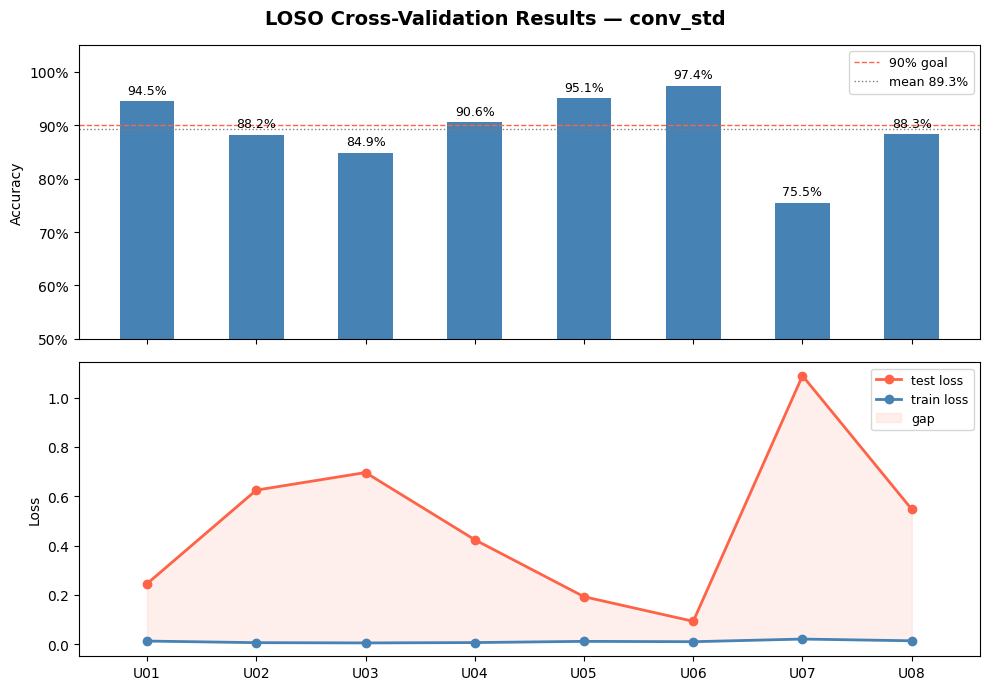

In [137]:
plot_loso_results("conv_std")

## Last test with LSTM model

In [138]:
class LSTMmodel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=config.input_size,
            hidden_size=config.hidden_size,
            num_layers=config.num_layers,
            dropout=config.dropout,
            batch_first=True,
        )
        self.head = nn.Linear(config.hidden_size, config.output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])

In [140]:
larger_config

ModelConfig(input_size=3, hidden_size=64, num_layers=4, output_size=20, dropout=0.3)

In [141]:
def run_loso_LSTM(
    experiment_name: str,
    config: ModelConfig,
    settings: TrainerSettings,
    loss_fn,
    device,
    preprocessor,
    model_tag: str = "base correct split",
    user_ids: list = ['U01', 'U02', 'U03', 'U04', 'U05', 'U06', 'U07', 'U08'],
) -> None:
    mlflow.set_experiment(experiment_name)
    datadir = Path.home() / ".cache/mads_datasets"

    for user_id in user_ids:
        factory = CorrectGesturesFactory(gesturesdatasetsettings, datadir=datadir)
        datasets = factory.create_dataset(holdout_user=user_id)
        streamers = factory.create_datastreamer(batchsize=32, preprocessor=preprocessor)

        settings.train_steps = len(streamers["train"])
        settings.valid_steps = len(streamers["valid"])
        
        with mlflow.start_run():
            mlflow.set_tag("model", f"{model_tag} hold out: {user_id}")
            mlflow.set_tag("dev", "Steven")

            trainer = Trainer(
                model=LSTMmodel(config=config),
                settings=settings,
                loss_fn=loss_fn,
                optimizer=optim.Adam,
                traindataloader=streamers["train"].stream(),
                validdataloader=streamers["valid"].stream(),
                scheduler=optim.lr_scheduler.ReduceLROnPlateau,
                device=device,
            )
            trainer.loop()

In [ ]:
run_loso(
    experiment_name="LSTM",
    model_tag="LSTM",
    config=larger_config,
    settings=std_settings,
    loss_fn=loss_fn,
    device=device,
    preprocessor=preprocessor,
)

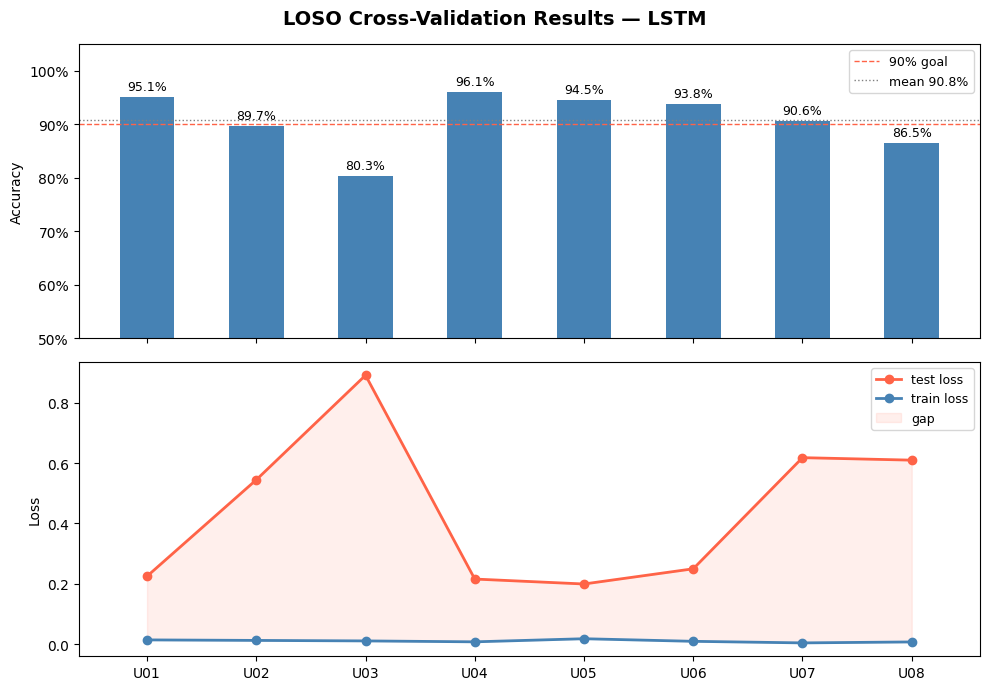

In [143]:
plot_loso_results("LSTM")

In [145]:
# drop out was still higher lets move it down
# this is an issue with hand tuning
larger_config.dropout = 0.1

In [ ]:
run_loso(
    experiment_name="LSTM_DO_0.1",
    model_tag="LSTM_DO_0.1",
    config=larger_config,
    settings=std_settings,
    loss_fn=loss_fn,
    device=device,
    preprocessor=preprocessor,
)

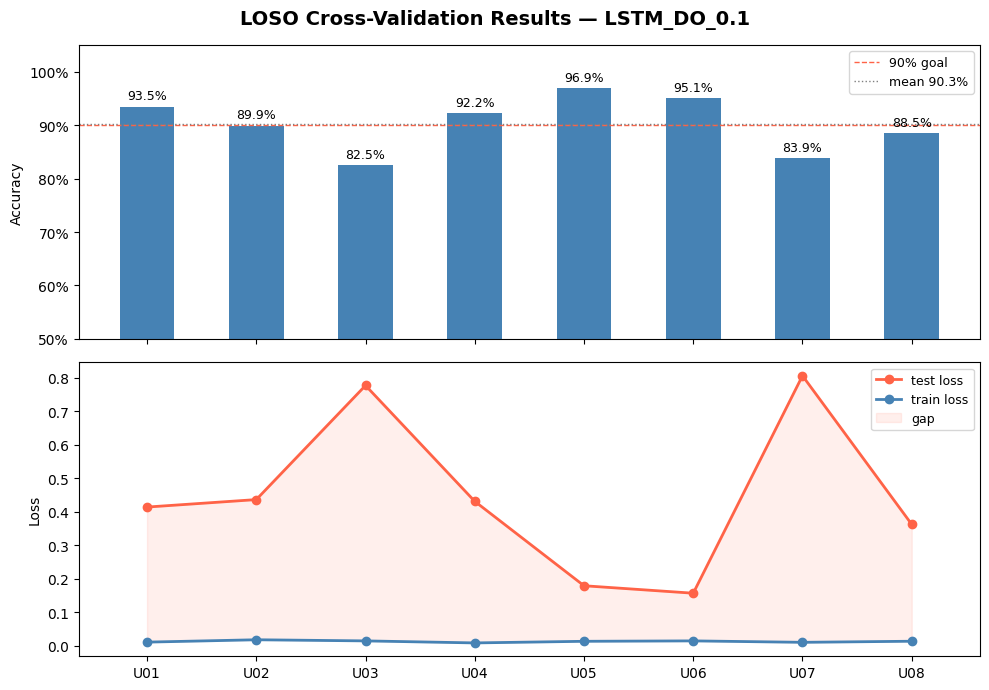

In [147]:
plot_loso_results("LSTM_DO_0.1")

In [148]:
# drop out seems to be helping a bit, lets do drop out 0.5 for the last model

larger_config.dropout = 0.5

In [ ]:
run_loso(
    experiment_name="LSTM_DO_0.5",
    model_tag="LSTM_DO_0.5",
    config=larger_config,
    settings=std_settings,
    loss_fn=loss_fn,
    device=device,
    preprocessor=preprocessor,
)

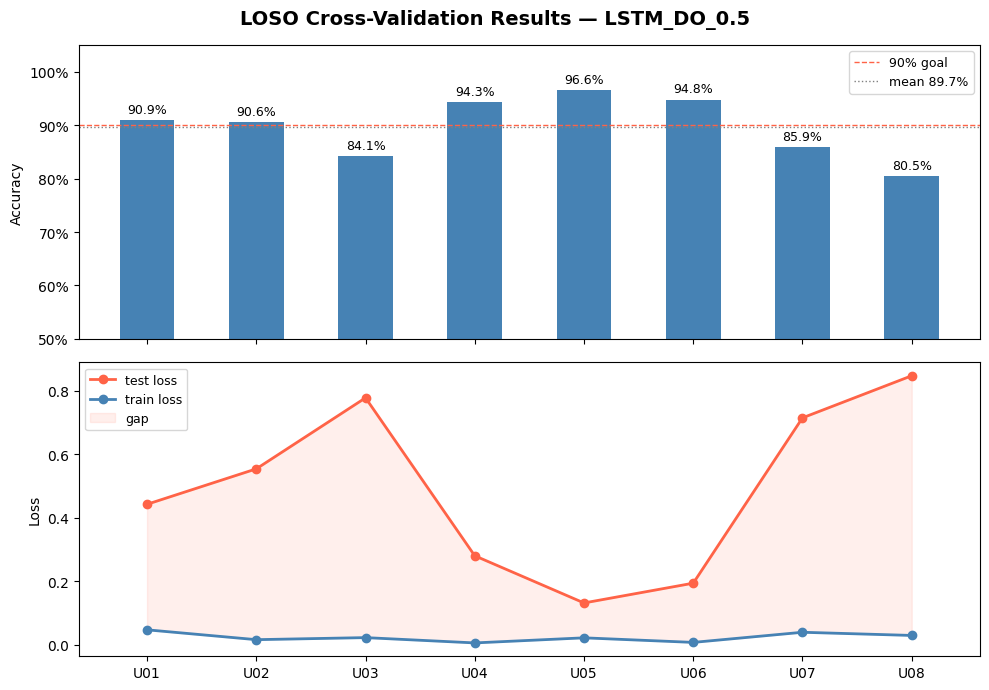

In [150]:
plot_loso_results("LSTM_DO_0.5")